#### Gathering the data

In [1]:
def any_keyword_in_string(string, keywords):
    for keyword in keywords:
        if keyword in string:
            return True
    return False

In [2]:
filters = ["pandas", "sklearn", "matplotlib", "seaborn"]
example_1 = "import numpy as np"
example_2 = "import pandas as pd"

print(
    any_keyword_in_string(example_1, filters), any_keyword_in_string(example_2, filters)
)

False True


In [3]:
from collections import defaultdict
from tqdm import tqdm
from datasets import Dataset


def filter_streaming_dataset(dataset, filters):
    filtered_dict = defaultdict(list)
    total = 0
    for sample in tqdm(iter(dataset)):
        total += 1
        if any_keyword_in_string(sample["content"], filters):
            for k, v in sample.items():
                filtered_dict[k].append(v)
    print(f"{len(filtered_dict['content'])/total:.2%} of data after filtering.")
    return Dataset.from_dict(filtered_dict)

In [4]:
# This cell will take a very long time to execute, so you should skip it and go to
# the next one!
from datasets import load_dataset

split = "train"  # "valid"
filters = ["pandas", "sklearn", "matplotlib", "seaborn"]

In [8]:
# data = load_dataset(f"transformersbook/codeparrot-{split}", split=split, streaming=True)
# filtered_data = filter_streaming_dataset(data, filters)

In [8]:
import os
os.environ["HF_DATASETS_OFFLINE"] = "1"  # forces offline mode, will error instead of trying to download

ds_train = load_dataset(
    "huggingface-course/codeparrot-ds-train",
    split="train[:40%]",
    cache_dir=r"C:\Users\satish.a.waghmare\.cache\huggingface\datasets",
)
ds_valid = load_dataset(
    "huggingface-course/codeparrot-ds-valid",
    split="validation[:40%]",
    cache_dir=r"C:\Users\satish.a.waghmare\.cache\huggingface\datasets",
)

In [9]:
from datasets import load_dataset, DatasetDict

# ds_train = load_dataset("huggingface-course/codeparrot-ds-train", split="train[:40%]")
# ds_valid = load_dataset("huggingface-course/codeparrot-ds-valid", split="validation[:40%]")

raw_datasets = DatasetDict(
    {
        "train": ds_train,  # .shuffle().select(range(50000)),
        "valid": ds_valid,  # .shuffle().select(range(500))
    }
)

raw_datasets

DatasetDict({
    train: Dataset({
        features: ['repo_name', 'path', 'copies', 'size', 'content', 'license'],
        num_rows: 242688
    })
    valid: Dataset({
        features: ['repo_name', 'path', 'copies', 'size', 'content', 'license'],
        num_rows: 1329
    })
})

In [10]:
for key in raw_datasets["train"][0]:
    print(f"{key.upper()}: {raw_datasets['train'][0][key][:200]}")

REPO_NAME: kmike/scikit-learn
PATH: sklearn/utils/__init__.py
COPIES: 3
SIZE: 10094
CONTENT: """
The :mod:`sklearn.utils` module includes various utilites.
"""

from collections import Sequence

import numpy as np
from scipy.sparse import issparse
import warnings

from .murmurhash import murm
LICENSE: bsd-3-clause


In [11]:
from transformers import AutoTokenizer

context_length = 128
tokenizer = AutoTokenizer.from_pretrained("huggingface-course/code-search-net-tokenizer")

outputs = tokenizer(
    raw_datasets["train"][:2]["content"],
    truncation=True,
    max_length=context_length,
    return_overflowing_tokens=True,
    return_length=True,
)

print(f"Input IDs length: {len(outputs['input_ids'])}")
print(f"Input chunk lengths: {(outputs['length'])}")
print(f"Chunk mapping: {outputs['overflow_to_sample_mapping']}")

tokenizer_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

C:\PythonVM\env2\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\satish.a.waghmare\.cache\huggingface\hub\models--huggingface-course--code-search-net-tokenizer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input IDs length: 34
Input chunk lengths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 117, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 41]
Chunk mapping: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [12]:
import torch

In [18]:
def tokenize(element):
    outputs = tokenizer(
        element["content"],
        truncation=True,
        max_length=context_length,
        return_overflowing_tokens=True,
        return_length=True,
    )
    input_batch = []
    for length, input_ids in zip(outputs["length"], outputs["input_ids"]):
        if length == context_length:
            input_batch.append(input_ids)
    return {"input_ids": input_batch}


tokenized_datasets = raw_datasets.map(
    tokenize, batched=True, remove_columns=raw_datasets["train"].column_names
)
tokenized_datasets

Map:   0%|          | 0/242688 [00:00<?, ? examples/s]

Map:   0%|          | 0/1329 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 6668823
    })
    valid: Dataset({
        features: ['input_ids'],
        num_rows: 36052
    })
})

#### Initializing a new model

In [19]:
from transformers import AutoTokenizer, GPT2LMHeadModel, AutoConfig

config = AutoConfig.from_pretrained(
    "gpt2",
    vocab_size=len(tokenizer),
    n_ctx=context_length,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

In [20]:
model = GPT2LMHeadModel(config)
model_size = sum(t.numel() for t in model.parameters())
print(f"GPT-2 size: {model_size/1000**2:.1f}M parameters")

GPT-2 size: 124.2M parameters


In [21]:
from transformers import DataCollatorForLanguageModeling

tokenizer.pad_token = tokenizer.eos_token
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

In [22]:
out = data_collator([tokenized_datasets["train"][i] for i in range(5)])
for key in out:
    print(f"{key} shape: {out[key].shape}")

input_ids shape: torch.Size([5, 128])
attention_mask shape: torch.Size([5, 128])
labels shape: torch.Size([5, 128])


In [23]:
from huggingface_hub import notebook_login

notebook_login()

In [24]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    output_dir="codeparrot-ds",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="steps",
    eval_steps=5_000,
    logging_steps=5_000,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    weight_decay=0.1,
    warmup_steps=1_000,
    lr_scheduler_type="cosine",
    learning_rate=5e-4,
    save_steps=5_000,
    fp16=True,
    push_to_hub=True,
)

In [25]:
trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    args=args,
    data_collator=data_collator,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["valid"],
)

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.
C:\PythonVM\env2\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss


In [ ]:
trainer.push_to_hub()

#### Code generation with a pipeline

In [26]:
import torch
from transformers import pipeline

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
pipe = pipeline(
    "text-generation", model="huggingface-course/codeparrot-ds", device=device
)

config.json:   0%|          | 0.00/938 [00:00<?, ?B/s]

C:\PythonVM\env2\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\satish.a.waghmare\.cache\huggingface\hub\models--huggingface-course--codeparrot-ds. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: huggingface-course/codeparrot-ds
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [27]:
txt = """\
# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create scatter plot with x, y
"""
print(pipe(txt, num_return_sequences=1)[0]["generated_text"])

Passing `generation_config` together with generation-related arguments=({'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create scatter plot with x, y
x_vals = np.random.normal(0, 1


C:\PythonVM\env2\Lib\site-packages\matplotlib\collections.py:1115: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


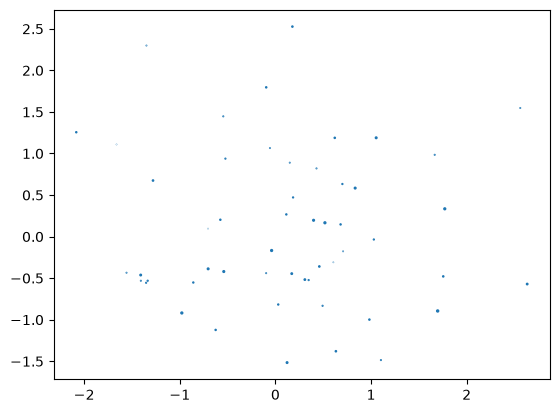

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# create some data
x = np.random.randn(100)
y = np.random.randn(100)
z = np.random.randn(100)

# create scatter plot with x, y
plt.scatter(x, y, z)

# create scatter

In [34]:
# !pip install matplotlib

In [48]:
import pandas as pd

txt = """\
# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create dataframe from x and y
"""
print(pipe(txt, num_return_sequences=1)[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create dataframe from x and y
df = pd.DataFrame({
    'x': x,
    '


In [49]:
# dataframe with profession, income and name
df = pd.DataFrame({'profession': x, 'income':y, 'name': z}) # 

# calculate the mean income per profession
profession = df.groupby(['profession']).mean()

# compute the

In [50]:
txt = """
# import random forest regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# fit random forest model with 300 estimators on X, y:
"""
print(pipe(txt, num_return_sequences=1)[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



# import random forest regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# fit random forest model with 300 estimators on X, y:
# use XGBoost to reduce memory usage
regressor = RandomForest


In [52]:
# import random forest regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

random_state = 3

# fit random forest model with 300 estimators on X, y:
rf = RandomForestRegressor(n_estimators=300, random_state=random_state, max_depth=3)
rf.fit(x, y)
rf

ValueError: Expected 2D array, got 1D array instead:
array=[-0.522723    1.0490092  -0.7043437  -1.4084613  -1.5566292   0.60600996
 -1.2804294   1.7547942  -2.0819294   1.6964563   0.21101747 -0.09671311
 -0.5449191   0.39913613 -0.0376347   1.1033019   0.11422765  0.15030175
 -0.3636122  -0.05694562  0.30780178 -1.7101684  -1.3481854   0.7432641
  0.17086543 -0.18398334  0.01843393  0.3475817  -0.5397597  -0.7783047
  0.19584526 -0.97837275  0.40825275 -1.7025836   1.0291556   0.47259748
  0.25602973  0.982691    1.6654744   1.0143701  -1.8408742  -1.279577
 -0.62481856  0.02609105  0.517659   -0.72574383  0.18676676 -0.75538296
 -0.6115178  -1.4066612  -0.9232333  -1.3516846  -0.97587323  1.0536418
 -0.9493989   2.6323822   0.4933179   0.18483612 -0.8583578   0.7003099
 -0.5756378   0.12200981  2.5600846  -0.0960599   1.1492733  -0.70317644
 -0.03498849  1.7708006  -0.6269671   1.8124485   0.7077519  -0.5624668
  0.6324077   0.97255445  0.62180996 -1.5702248  -0.72713715 -0.24751863

#### Training with 🤗 Accelerate

In [53]:
keytoken_ids = []
for keyword in [
    "plt",
    "pd",
    "sk",
    "fit",
    "predict",
    " plt",
    " pd",
    " sk",
    " fit",
    " predict",
    "testtest",
]:
    ids = tokenizer([keyword]).input_ids[0]
    if len(ids) == 1:
        keytoken_ids.append(ids[0])
    else:
        print(f"Keyword has not single token: {keyword}")

Keyword has not single token: testtest


In [54]:
from torch.nn import CrossEntropyLoss
import torch


def keytoken_weighted_loss(inputs, logits, keytoken_ids, alpha=1.0):
    # Shift so that tokens < n predict n
    shift_labels = inputs[..., 1:].contiguous()
    shift_logits = logits[..., :-1, :].contiguous()
    # Calculate per-token loss
    loss_fct = CrossEntropyLoss(reduce=False)
    loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    # Resize and average loss per sample
    loss_per_sample = loss.view(shift_logits.size(0), shift_logits.size(1)).mean(axis=1)
    # Calculate and scale weighting
    weights = torch.stack([(inputs == kt).float() for kt in keytoken_ids]).sum(
        axis=[0, 2]
    )
    weights = alpha * (1.0 + weights)
    # Calculate weighted average
    weighted_loss = (loss_per_sample * weights).mean()
    return weighted_loss

In [55]:
from torch.utils.data.dataloader import DataLoader

tokenized_datasets.set_format("torch")
train_dataloader = DataLoader(tokenized_datasets["train"], batch_size=32, shuffle=True)
eval_dataloader = DataLoader(tokenized_datasets["valid"], batch_size=32)

In [56]:
weight_decay = 0.1


def get_grouped_params(model, no_decay=["bias", "LayerNorm.weight"]):
    params_with_wd, params_without_wd = [], []
    for n, p in model.named_parameters():
        if any(nd in n for nd in no_decay):
            params_without_wd.append(p)
        else:
            params_with_wd.append(p)
    return [
        {"params": params_with_wd, "weight_decay": weight_decay},
        {"params": params_without_wd, "weight_decay": 0.0},
    ]

In [57]:
def evaluate():
    model.eval()
    losses = []
    for step, batch in enumerate(eval_dataloader):
        with torch.no_grad():
            outputs = model(batch["input_ids"], labels=batch["input_ids"])

        losses.append(accelerator.gather(outputs.loss))
    loss = torch.mean(torch.cat(losses))
    try:
        perplexity = torch.exp(loss)
    except OverflowError:
        perplexity = float("inf")
    return loss.item(), perplexity.item()

In [58]:
model = GPT2LMHeadModel(config)

In [59]:
from torch.optim import AdamW

optimizer = AdamW(get_grouped_params(model), lr=5e-4)

In [61]:
from accelerate import Accelerator
accelerator = Accelerator(mixed_precision="fp16")
model, optimizer, train_dataloader, eval_dataloader = accelerator.prepare(
    model, optimizer, train_dataloader, eval_dataloader
)

In [62]:
from transformers import get_scheduler

num_train_epochs = 1
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_train_epochs * num_update_steps_per_epoch

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=1_000,
    num_training_steps=num_training_steps,
)

In [63]:
from huggingface_hub import Repository, get_full_repo_name

model_name = "codeparrot-ds-accelerate"
repo_name = get_full_repo_name(model_name)
repo_name

ImportError: cannot import name 'Repository' from 'huggingface_hub' (C:\PythonVM\env2\Lib\site-packages\huggingface_hub\__init__.py)

In [1]:
output_dir = "codeparrot-ds-accelerate"
repo = Repository(output_dir, clone_from=repo_name)

NameError: name 'Repository' is not defined

In [3]:
evaluate()

NameError: name 'evaluate' is not defined

In [2]:
from tqdm.notebook import tqdm

gradient_accumulation_steps = 8
eval_steps = 5_000

model.train()
completed_steps = 0
for epoch in range(num_train_epochs):
    for step, batch in tqdm(
        enumerate(train_dataloader, start=1), total=num_training_steps
    ):
        logits = model(batch["input_ids"]).logits
        loss = keytoken_weighted_loss(batch["input_ids"], logits, keytoken_ids)
        if step % 100 == 0:
            accelerator.print(
                {
                    "samples": step * samples_per_step,
                    "steps": completed_steps,
                    "loss/train": loss.item() * gradient_accumulation_steps,
                }
            )
        loss = loss / gradient_accumulation_steps
        accelerator.backward(loss)
        if step % gradient_accumulation_steps == 0:
            accelerator.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            completed_steps += 1
        if (step % (eval_steps * gradient_accumulation_steps)) == 0:
            eval_loss, perplexity = evaluate()
            accelerator.print({"loss/eval": eval_loss, "perplexity": perplexity})
            model.train()
            accelerator.wait_for_everyone()
            unwrapped_model = accelerator.unwrap_model(model)
            unwrapped_model.save_pretrained(output_dir, save_function=accelerator.save)
            if accelerator.is_main_process:
                tokenizer.save_pretrained(output_dir)
                repo.push_to_hub(
                    commit_message=f"Training in progress step {step}", blocking=False
                )

NameError: name 'model' is not defined